<div style="
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 30px 40px ;
    background-color: #ffffff;
    border-radius: 12px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
    margin-bottom: 20px;
">
    <img 
        src="https://raw.githubusercontent.com/sarasadatnasr/Machine_Learning_Final_Project/728689a356aa43073d6552462b8ba6ab8aca9218/Logo/ut-logo.png"
        alt="University Logo"
        style="height: 120px;"
    >
    <div style="
        text-align: center;
        font-family: 'Segoe UI', Arial, sans-serif;
        color: #222;
        line-height: 1.4;
    ">
        <h1 style="margin: 0; font-size: 32px; color: #2e98c6;">Machine Learning - Final Project</h1>
        <h3 style="margin: 6px 0 12px; font-weight: 500; color: #555;">Clustering</h3>
        <p style="margin: 0; font-size: 15px;">
            <strong>Sara Sadat Nasr Azadani</strong> ·
            <strong>Alireza Farshi</strong> ·
            <strong>Saeid Rezaie Noor</strong>
        </p>
    </div>
    <img 
        src="https://raw.githubusercontent.com/sarasadatnasr/Machine_Learning_Final_Project/7dab869a805ff296327c1fdcbc6954e3478073e7/Logo/co-w-9.png"
        alt="Faculty Logo"
        style="height: 120px;"
    >
</div>

<div style="
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 30px 40px ;
    background-color: #ffffff;
    border-radius: 12px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
    margin-bottom: 20px;
    color: #555;
    font-size: 20px;
">
📚Import Libraries
</div>

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import warnings

from mpl_toolkits.mplot3d import Axes3D

import joblib
import json
import os
from datetime import datetime
import random

In [10]:
RANDOM_STATE = random.randint(0, 2**32 - 1)
print(RANDOM_STATE)

4220373295


<div style="
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 30px 40px ;
    background-color: #ffffff;
    border-radius: 12px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
    margin-bottom: 20px;
    color: #555;
    font-size: 20px;
">
🎨 Set Environments theme
</div>

In [11]:
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

<div style="
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 30px 40px ;
    background-color: #ffffff;
    border-radius: 12px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
    margin-bottom: 20px;
    color: #555;
    font-size: 20px;
">
📁 Load extracted features
</div>

In [12]:
print("Loading data...")
features_df = pd.read_csv('./Data_Cleaning_and_Feature_Extraction/audio_features.csv')
print(f"Dataset shape: {features_df.shape}")

# Prepare data
X = features_df.select_dtypes(include=[np.number])
true_labels = features_df['language']
language_map = {lang: i for i, lang in enumerate(true_labels.unique())}
y_true = true_labels.map(language_map).values

print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"True number of clusters (languages): {len(np.unique(y_true))}")
print("Languages:", true_labels.unique())


Loading data...
Dataset shape: (2848, 109)
Number of samples: 2848
Number of features: 106
True number of clusters (languages): 4
Languages: ['German' 'Italian' 'Korean' 'Spanish']


Reduced to 36 PCA components (95% variance retained)
Running t-SNE for 2D visualization...


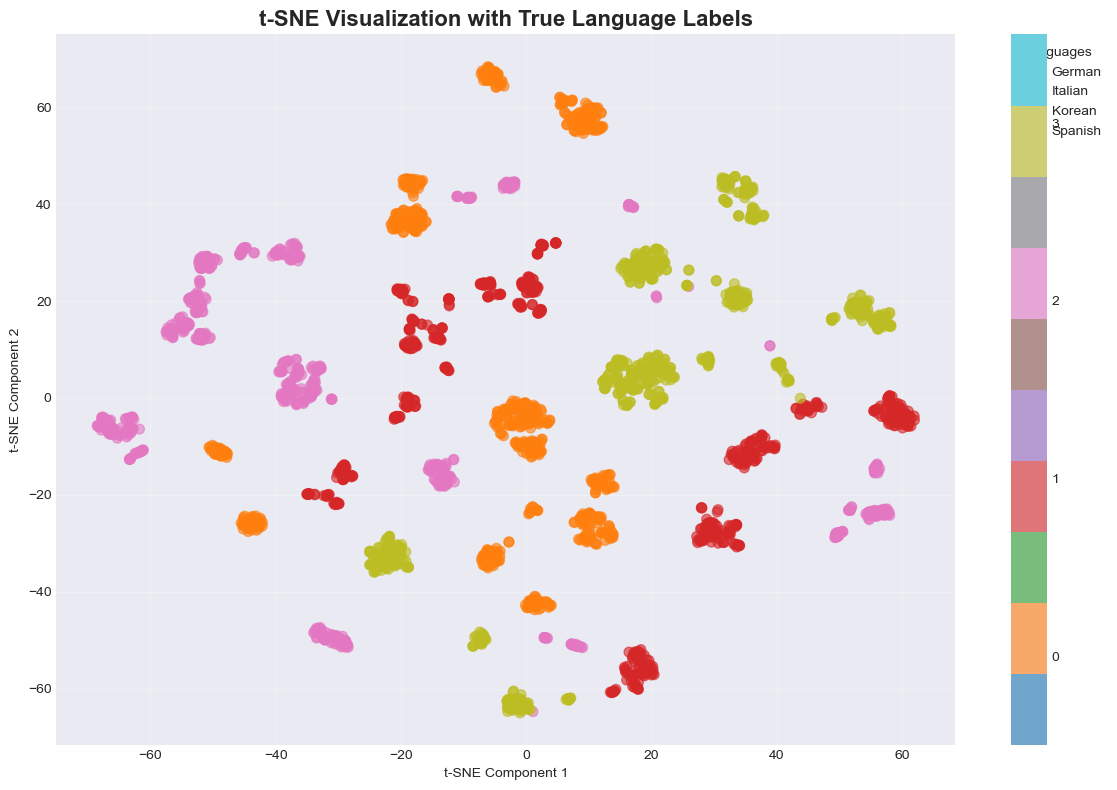

In [4]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA for dimensionality reduction
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)
print(f"Reduced to {X_pca.shape[1]} PCA components (95% variance retained)")


# Visualize data in 2D using t-SNE
print("Running t-SNE for 2D visualization...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_pca)

# Plot true labels
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_true, cmap='tab10', alpha=0.6, s=50)
plt.colorbar(scatter, ticks=range(len(language_map)))
plt.clim(-0.5, len(language_map)-0.5)
plt.title('t-SNE Visualization with True Language Labels', fontsize=16, fontweight='bold')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True, alpha=0.3)

# Add legend
for lang, idx in language_map.items():
    plt.scatter([], [], label=lang, color=plt.cm.tab10(idx))
plt.legend(title='Languages', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('./Clustering/tsne_true_labels.png', dpi=300, bbox_inches='tight')
plt.show()

<div style="
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 30px 40px ;
    background-color: #ffffff;
    border-radius: 12px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
    margin-bottom: 20px;
    color: #555;
    font-size: 20px;
">
💯 Determining Optimal Number of Clusters
</div>

In [13]:
# Elbow Method and Silhouette Analysis
def evaluate_clusters_range(X, max_clusters=15):
    wcss = []  # Within-Cluster Sum of Squares
    silhouette_scores = []
    calinski_scores = []
    davies_scores = []
    
    for k in range(2, max_clusters + 1):
        print(f"  Evaluating k={k}...", end='\r')
        
        # KMeans clustering
        kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        kmeans.fit(X)
        
        # Calculate metrics
        wcss.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(X, kmeans.labels_))
        calinski_scores.append(calinski_harabasz_score(X, kmeans.labels_))
        davies_scores.append(davies_bouldin_score(X, kmeans.labels_))
    
    return wcss, silhouette_scores, calinski_scores, davies_scores


# Evaluate cluster range
print("Evaluating optimal number of clusters...")
wcss, silhouette_scores, calinski_scores, davies_scores = evaluate_clusters_range(X_pca, max_clusters=15)



Evaluating optimal number of clusters...


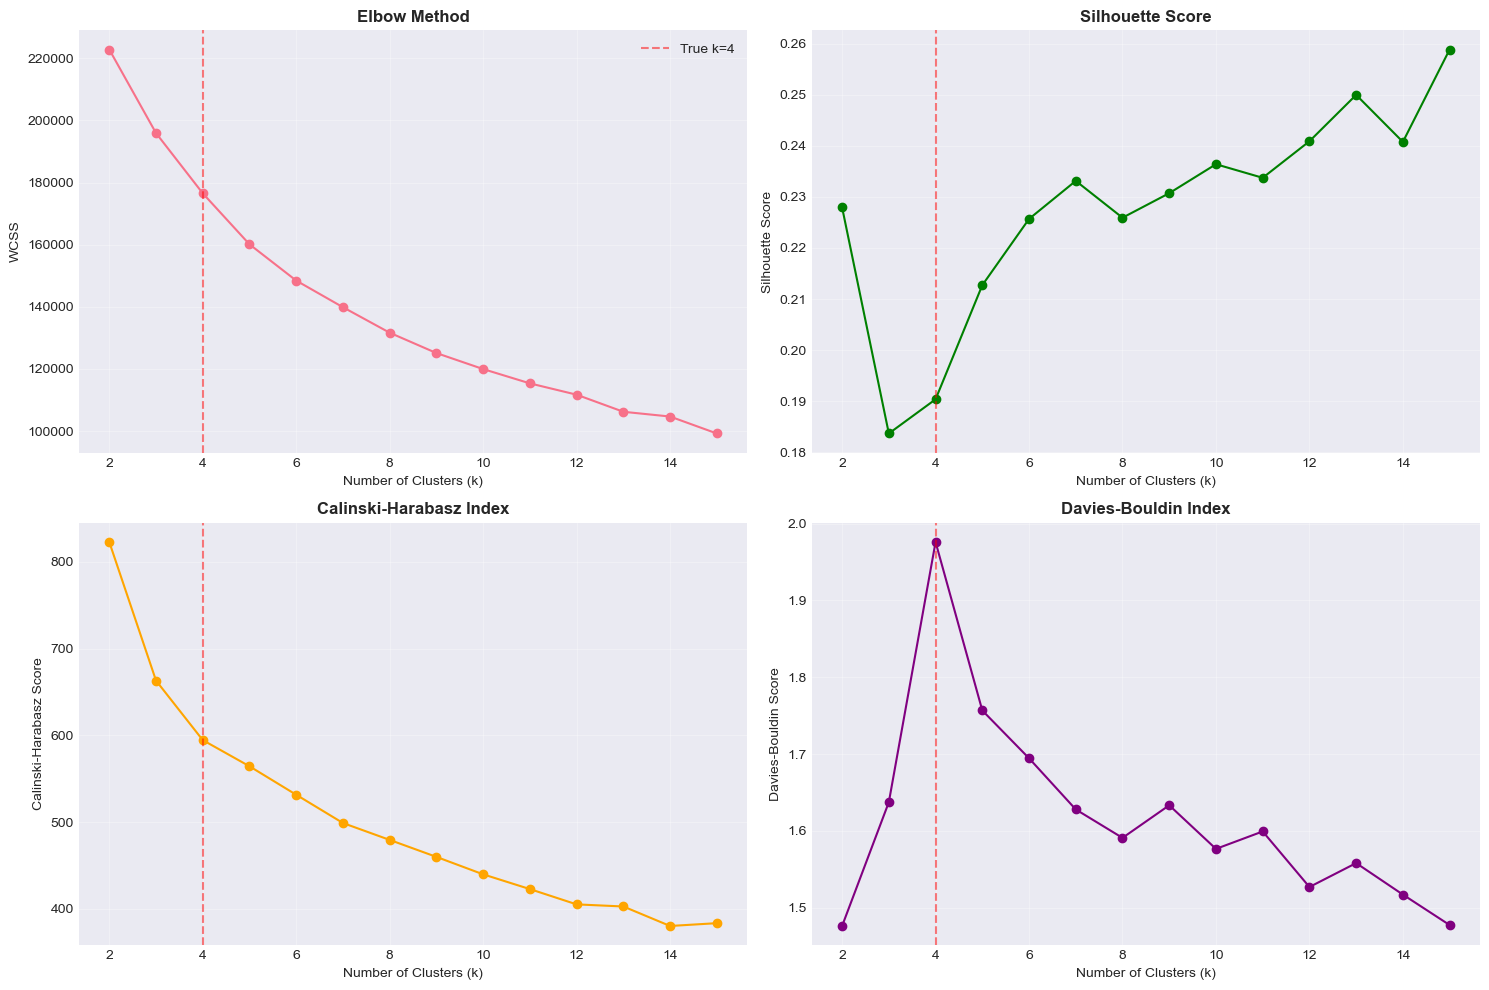

In [14]:

# Plot evaluation metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Elbow Method
k_range = range(2, 16)
axes[0,0].plot(k_range, wcss, marker='o')
axes[0,0].set_xlabel('Number of Clusters (k)')
axes[0,0].set_ylabel('WCSS')
axes[0,0].set_title('Elbow Method', fontweight='bold')
axes[0,0].grid(True, alpha=0.3)
axes[0,0].axvline(x=4, color='r', linestyle='--', alpha=0.5, label='True k=4')
axes[0,0].legend()

# Silhouette Score
axes[0,1].plot(k_range, silhouette_scores, marker='o', color='green')
axes[0,1].set_xlabel('Number of Clusters (k)')
axes[0,1].set_ylabel('Silhouette Score')
axes[0,1].set_title('Silhouette Score', fontweight='bold')
axes[0,1].grid(True, alpha=0.3)
axes[0,1].axvline(x=4, color='r', linestyle='--', alpha=0.5)

# Calinski-Harabasz Index (higher is better)
axes[1,0].plot(k_range, calinski_scores, marker='o', color='orange')
axes[1,0].set_xlabel('Number of Clusters (k)')
axes[1,0].set_ylabel('Calinski-Harabasz Score')
axes[1,0].set_title('Calinski-Harabasz Index', fontweight='bold')
axes[1,0].grid(True, alpha=0.3)
axes[1,0].axvline(x=4, color='r', linestyle='--', alpha=0.5)

# Davies-Bouldin Index (lower is better)
axes[1,1].plot(k_range, davies_scores, marker='o', color='purple')
axes[1,1].set_xlabel('Number of Clusters (k)')
axes[1,1].set_ylabel('Davies-Bouldin Score')
axes[1,1].set_title('Davies-Bouldin Index', fontweight='bold')
axes[1,1].grid(True, alpha=0.3)
axes[1,1].axvline(x=4, color='r', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('./Clustering/cluster_evaluation_metrics.png', dpi=300, bbox_inches='tight')
plt.show()


In [15]:
# Find optimal k based on silhouette score
optimal_k_silhouette = k_range[np.argmax(silhouette_scores)]
optimal_k_calinski = k_range[np.argmax(calinski_scores)]
optimal_k_davies = k_range[np.argmin(davies_scores)]

print(f"\nOptimal k based on Silhouette Score: {optimal_k_silhouette}")
print(f"Optimal k based on Calinski-Harabasz: {optimal_k_calinski}")
print(f"Optimal k based on Davies-Bouldin: {optimal_k_davies}")
print(f"True number of clusters (languages): 4")


Optimal k based on Silhouette Score: 15
Optimal k based on Calinski-Harabasz: 2
Optimal k based on Davies-Bouldin: 2
True number of clusters (languages): 4


<div style="
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 30px 40px ;
    background-color: #ffffff;
    border-radius: 12px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
    margin-bottom: 20px;
    color: #555;
    font-size: 20px;
">
✨ Clustering Algorithms
</div>

In [18]:
# Define clustering algorithms with optimized DBSCAN parameters
clustering_algorithms = {
    'K-Means (k=4)': KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10),
    'K-Means (k=optimal)': KMeans(n_clusters=optimal_k_silhouette, random_state=RANDOM_STATE, n_init=10),
    'Agglomerative (k=4)': AgglomerativeClustering(n_clusters=4),
    'Agglomerative (k=optimal)': AgglomerativeClustering(n_clusters=optimal_k_silhouette),
    'Gaussian Mixture (k=4)': GaussianMixture(n_components=4, random_state=RANDOM_STATE),
    'Gaussian Mixture (k=optimal)': GaussianMixture(n_components=optimal_k_silhouette, random_state=RANDOM_STATE),
    'DBSCAN (eps=2.5)': DBSCAN(eps=2.5, min_samples=10),  # Increased min_samples
    'DBSCAN (eps=3.0)': DBSCAN(eps=3.0, min_samples=10),  # Increased min_samples
    'DBSCAN (eps=3.5)': DBSCAN(eps=3.5, min_samples=10),  # Increased min_samples
    'Spectral Clustering': SpectralClustering(n_clusters=4, eigen_solver='arpack', affinity='nearest_neighbors',random_state=RANDOM_STATE)
}


# Apply clustering algorithms and evaluate
results = {}
cluster_labels = {}

for name, algorithm in clustering_algorithms.items():
    print(f"Applying {name}...")
    
    if 'Gaussian Mixture' in name:
        # GMM returns probabilities, need to predict clusters
        algorithm.fit(X_pca)
        labels = algorithm.predict(X_pca)
    else:
        # Other algorithms
        if 'DBSCAN' in name:
            labels = algorithm.fit_predict(X_pca)
        else:
            algorithm.fit(X_pca)
            labels = algorithm.labels_
    
    # Store results
    cluster_labels[name] = labels
    
    # Calculate evaluation metrics
    n_clusters = len(np.unique(labels[labels != -1])) if -1 in labels else len(np.unique(labels))
    
    if n_clusters > 1:  # Need at least 2 clusters for silhouette score
        try:
            silhouette = silhouette_score(X_pca, labels) if n_clusters > 1 else -1
        except:
            silhouette = -1
    else:
        silhouette = -1
    
    results[name] = {
        'n_clusters_found': int(n_clusters),  # Convert to Python int
        'silhouette_score': float(silhouette) if silhouette != -1 else -1,
        'calinski_harabasz': float(calinski_harabasz_score(X_pca, labels)) if n_clusters > 1 else -1,
        'davies_bouldin': float(davies_bouldin_score(X_pca, labels)) if n_clusters > 1 else -1
    }


# Create results DataFrame
results_df = pd.DataFrame(results).T
print("\nClustering Results:")
print(results_df)


Applying K-Means (k=4)...
Applying K-Means (k=optimal)...
Applying Agglomerative (k=4)...
Applying Agglomerative (k=optimal)...
Applying Gaussian Mixture (k=4)...
Applying Gaussian Mixture (k=optimal)...
Applying DBSCAN (eps=2.5)...
Applying DBSCAN (eps=3.0)...
Applying DBSCAN (eps=3.5)...
Applying Spectral Clustering...

Clustering Results:
                              n_clusters_found  silhouette_score  \
K-Means (k=4)                              4.0          0.190365   
K-Means (k=optimal)                       15.0          0.258844   
Agglomerative (k=4)                        4.0          0.194719   
Agglomerative (k=optimal)                 15.0          0.264104   
Gaussian Mixture (k=4)                     4.0          0.195038   
Gaussian Mixture (k=optimal)              15.0          0.244001   
DBSCAN (eps=2.5)                          17.0         -0.235068   
DBSCAN (eps=3.0)                          29.0         -0.077055   
DBSCAN (eps=3.5)                          43

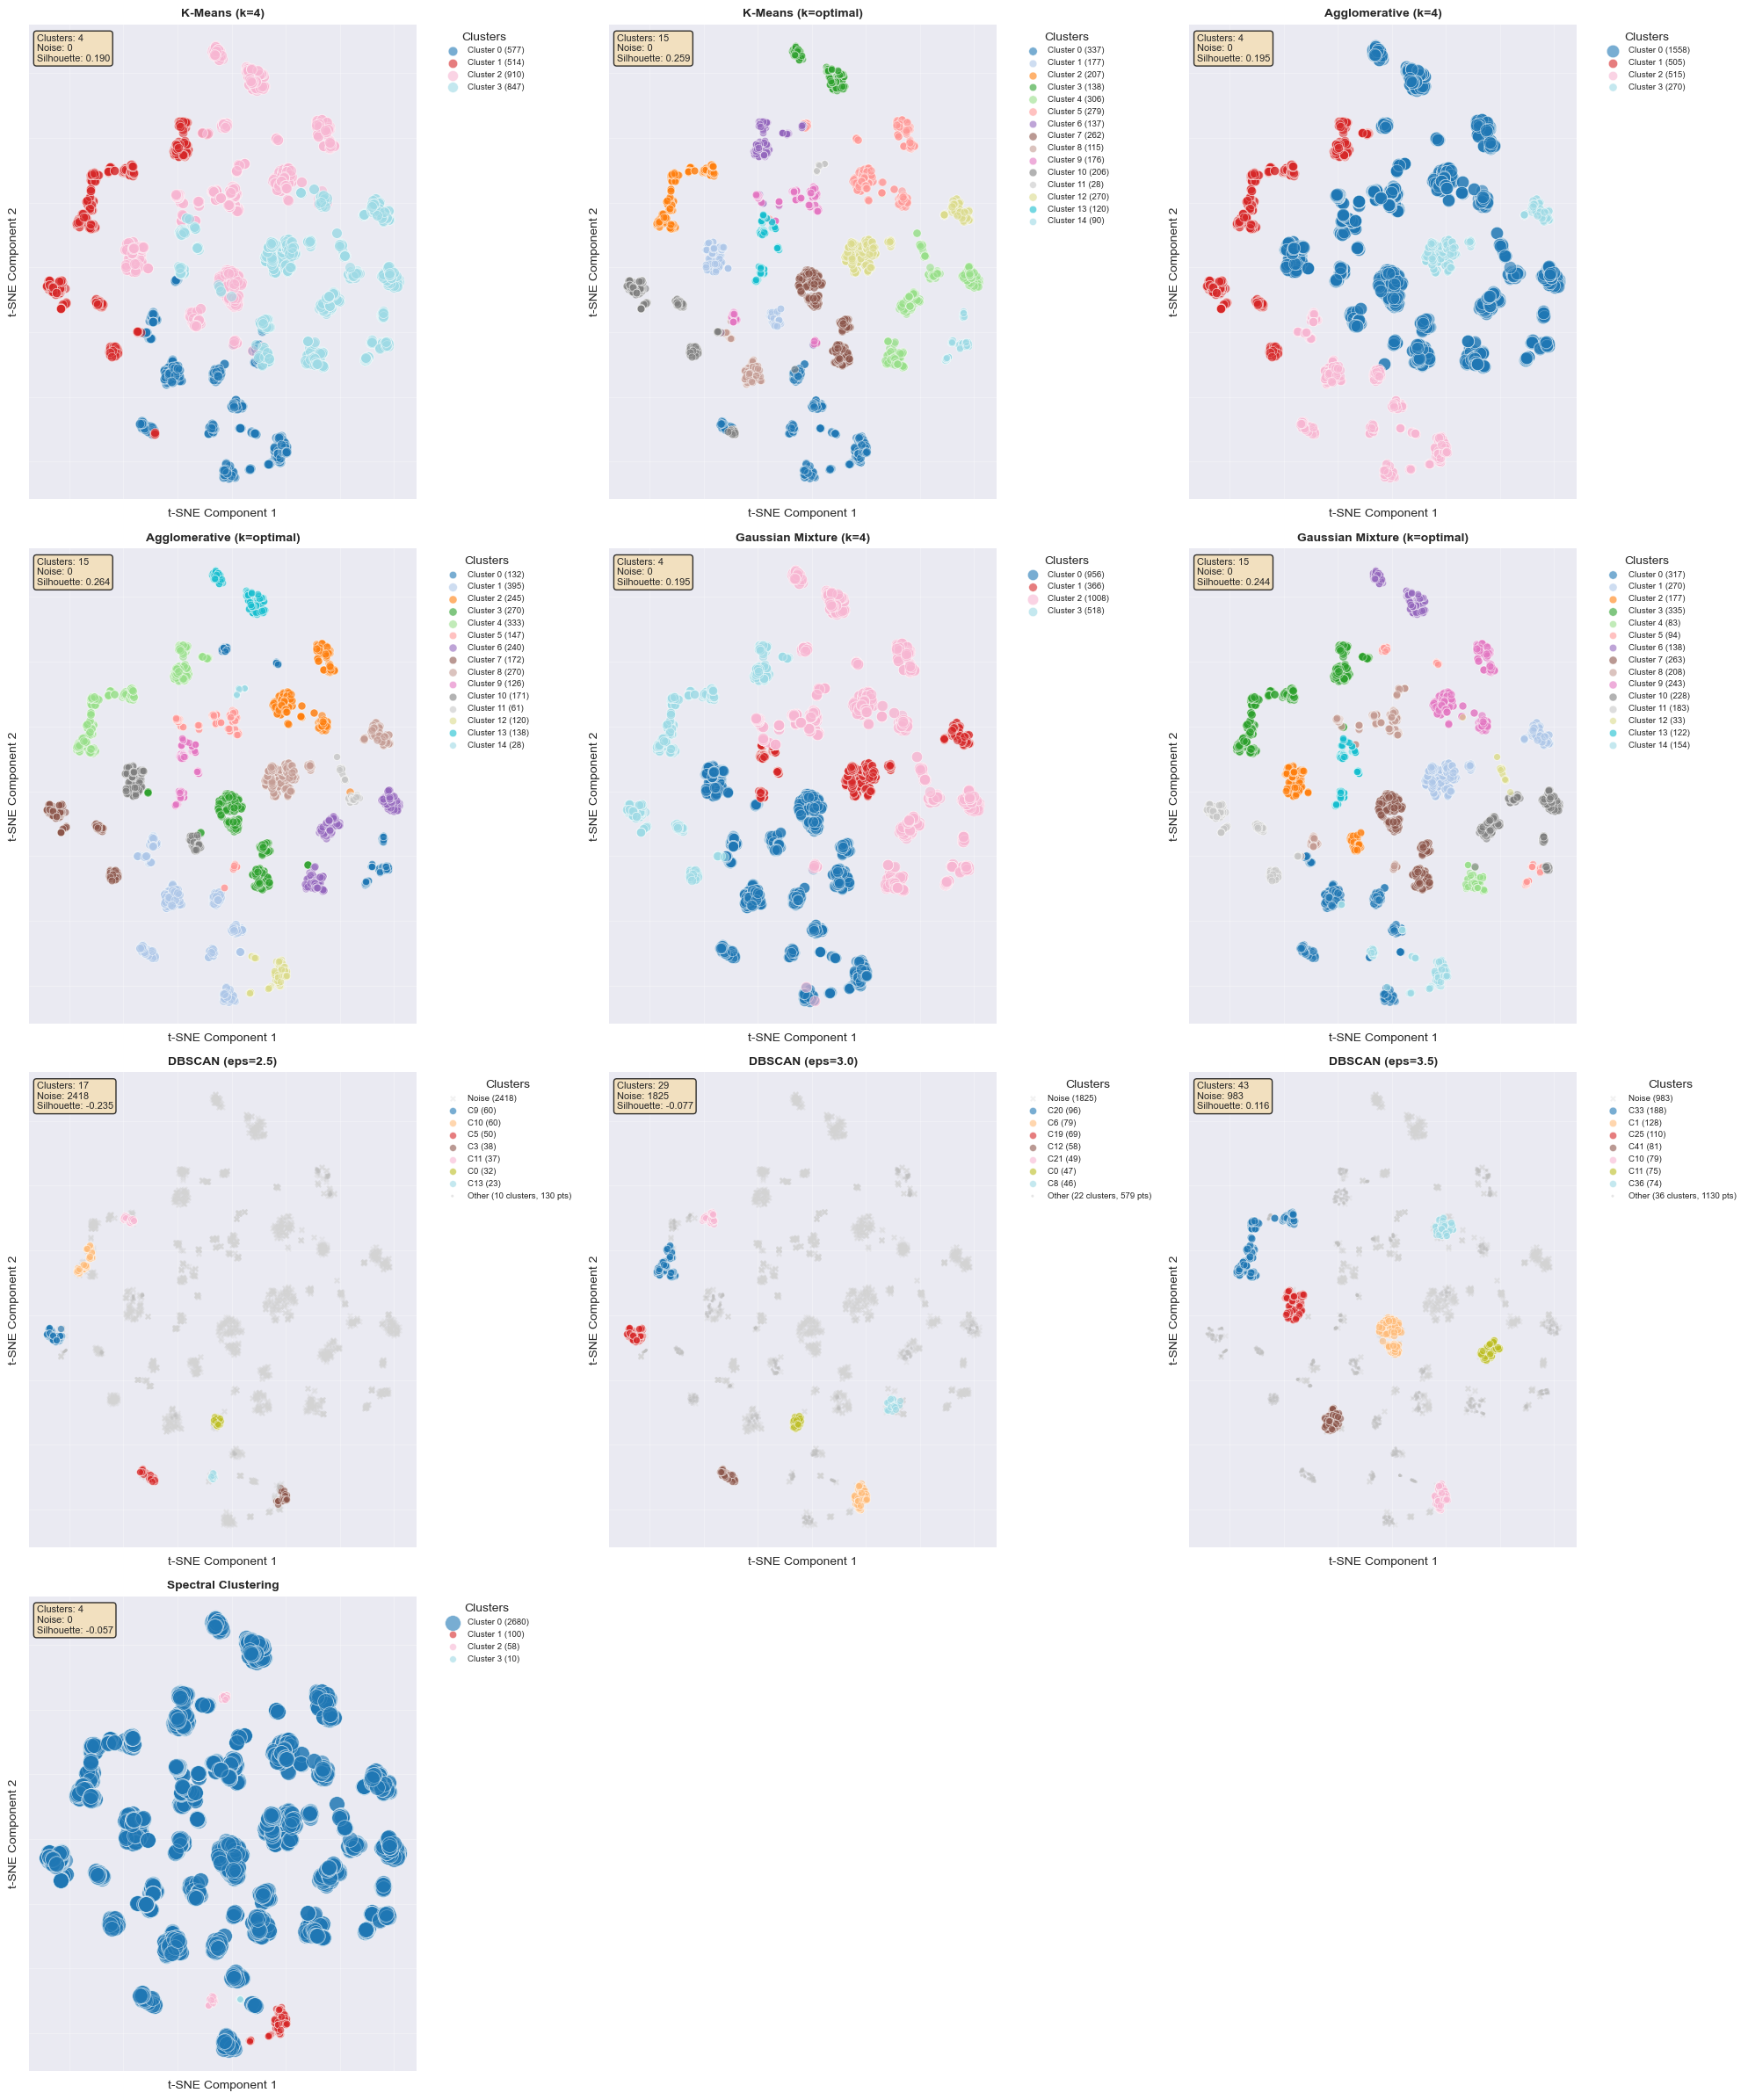

In [19]:
def visualize_clusters_smart(X_2d, labels, title, ax, max_clusters_in_legend=10):
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels) if -1 not in unique_labels else len(unique_labels) - 1
    
    # Handle noise points separately
    noise_mask = labels == -1
    if np.sum(noise_mask) > 0:
        ax.scatter(X_2d[noise_mask, 0], X_2d[noise_mask, 1],
                  c='lightgray', marker='x', s=15, alpha=0.3, 
                  label=f'Noise ({int(np.sum(noise_mask))})', edgecolors='none')
    
    # Separate non-noise clusters
    non_noise_labels = [int(label) for label in unique_labels if label != -1]  # Convert to int
    
    if len(non_noise_labels) <= max_clusters_in_legend:
        # If we have few clusters, show them all
        colors = plt.cm.tab20(np.linspace(0, 1, len(non_noise_labels)))
        
        for i, label in enumerate(non_noise_labels):
            mask = labels == label
            cluster_size = int(np.sum(mask))
            ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                      c=[colors[i]], marker='o', s=30 + cluster_size/20,
                      alpha=0.6, label=f'Cluster {label} ({cluster_size})',
                      edgecolors='w', linewidth=0.5)
    else:
        # If we have many clusters, group small ones
        cluster_sizes = {}
        for label in non_noise_labels:
            cluster_sizes[label] = int(np.sum(labels == label))
        
        # Sort clusters by size
        sorted_clusters = sorted(cluster_sizes.items(), key=lambda x: x[1], reverse=True)
        
        # Keep top clusters
        top_clusters = sorted_clusters[:max_clusters_in_legend-1]
        other_clusters = sorted_clusters[max_clusters_in_legend-1:]
        
        # Plot top clusters
        colors = plt.cm.tab20(np.linspace(0, 1, len(top_clusters)))
        for i, (label, size) in enumerate(top_clusters):
            mask = labels == label
            ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                      c=[colors[i]], marker='o', s=30 + size/20,
                      alpha=0.6, label=f'C{label} ({size})',
                      edgecolors='w', linewidth=0.5)
        
        # Plot other clusters as one group
        if other_clusters:
            other_labels = [label for label, _ in other_clusters]
            other_mask = np.isin(labels, other_labels)
            if np.sum(other_mask) > 0:
                total_other = int(sum(size for _, size in other_clusters))
                ax.scatter(X_2d[other_mask, 0], X_2d[other_mask, 1],
                          c='silver', marker='.', s=20,
                          alpha=0.4, label=f'Other ({len(other_clusters)} clusters, {total_other} pts)',
                          edgecolors='none')
    
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('t-SNE Component 1')
    ax.set_ylabel('t-SNE Component 2')
    
    # Place legend outside
    ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1), 
             fontsize=7, framealpha=0.9, title='Clusters')
    ax.grid(True, alpha=0.3)
    ax.set_xticklabels([])
    ax.set_yticklabels([])


# Create visualization grid with better layout
n_algorithms = len(clustering_algorithms)
n_cols = 3
n_rows = (n_algorithms + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 6*n_rows))
axes = axes.flatten()

for idx, (name, labels) in enumerate(cluster_labels.items()):
    if idx < len(axes):
        # Adjust max_clusters_in_legend based on algorithm type
        if 'DBSCAN' in name:
            max_legend_clusters = 8  # Fewer for DBSCAN
        else:
            max_legend_clusters = 15
        
        visualize_clusters_smart(X_tsne, labels, name, axes[idx], 
                                max_clusters_in_legend=max_legend_clusters)
        
        # Add metrics text box
        unique_labels = np.unique(labels)
        n_clusters_found = len(unique_labels) if -1 not in unique_labels else len(unique_labels) - 1
        noise_count = int(np.sum(labels == -1)) if -1 in labels else 0
        
        metrics_text = (f"Clusters: {n_clusters_found}\n"
                       f"Noise: {noise_count}\n"
                       f"Silhouette: {results[name]['silhouette_score']:.3f}")
        
        axes[idx].text(0.02, 0.98, metrics_text,
                      transform=axes[idx].transAxes,
                      fontsize=8,
                      verticalalignment='top',
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Hide empty subplots
for idx in range(len(clustering_algorithms), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig('./Clustering/clustering_results_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

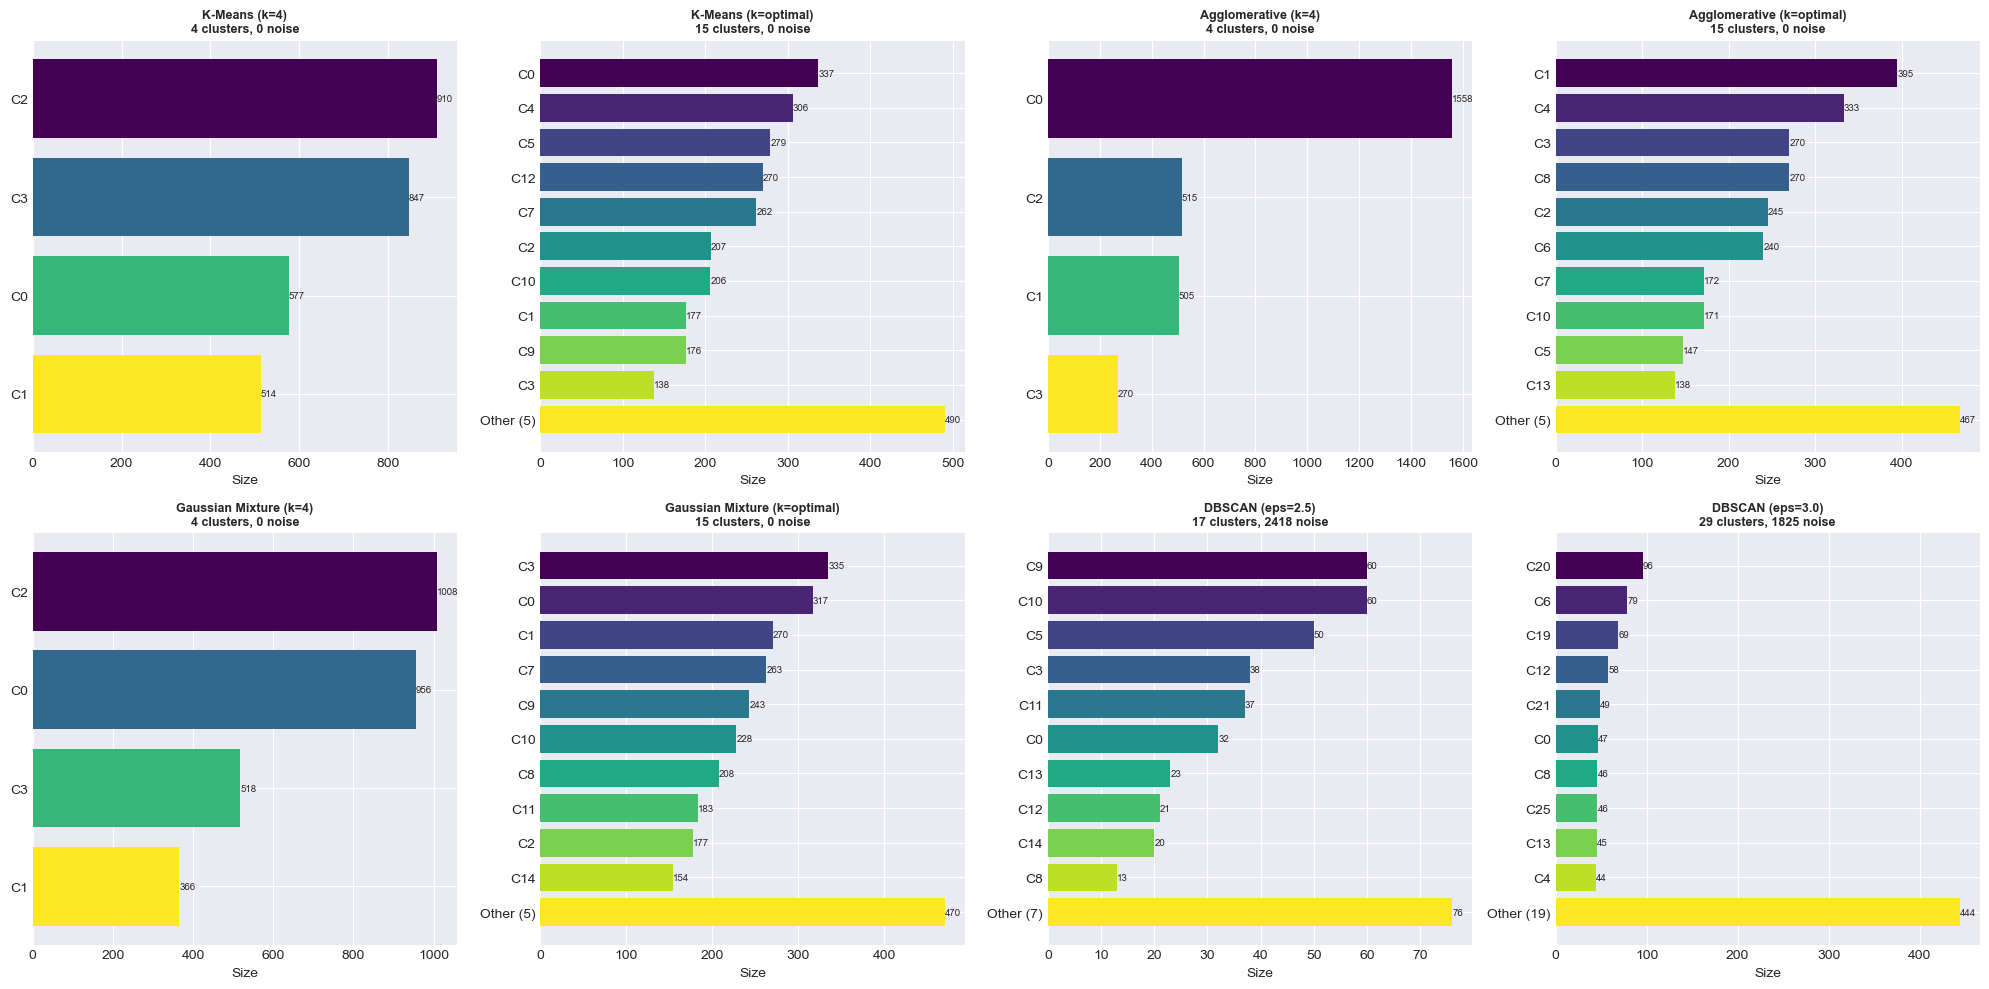

In [20]:
def create_cluster_report(labels, true_labels, algorithm_name):
    """Create a detailed report for clusters"""
    unique_labels = np.unique(labels)
    
    report = {
        'algorithm': algorithm_name,
        'total_samples': int(len(labels)),
        'noise_points': int(np.sum(labels == -1)) if -1 in labels else 0,
        'clusters_found': int(len(unique_labels)) if -1 not in unique_labels else int(len(unique_labels) - 1),
        'cluster_details': []
    }
    
    # Analyze each cluster
    for label in unique_labels:
        if label == -1:
            continue  # Skip noise for detailed analysis
        
        mask = labels == label
        cluster_size = int(np.sum(mask))
        cluster_languages = true_labels[mask]
        
        # Language distribution
        lang_counts = pd.Series(cluster_languages).value_counts()
        dominant_lang = lang_counts.idxmax()
        purity = float(lang_counts.max() / cluster_size)
        
        # Convert to Python types
        cluster_info = {
            'cluster_id': int(label),
            'size': cluster_size,
            'dominant_language': str(dominant_lang),
            'purity': purity,
            'language_distribution': {str(k): int(v) for k, v in dict(lang_counts).items()}
        }
        
        report['cluster_details'].append(cluster_info)
    
    # Sort clusters by size
    report['cluster_details'].sort(key=lambda x: x['size'], reverse=True)
    
    return report

# Create reports for all algorithms
reports = {}
for name, labels in cluster_labels.items():
    reports[name] = create_cluster_report(labels, true_labels, name)


# Create summary visualization of cluster sizes
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, (name, report) in enumerate(reports.items()):
    if idx < len(axes):
        cluster_details = report['cluster_details']
        
        if cluster_details:
            # Get top 10 clusters by size
            top_n = min(10, len(cluster_details))
            cluster_ids = [f"C{d['cluster_id']}" for d in cluster_details[:top_n]]
            cluster_sizes = [d['size'] for d in cluster_details[:top_n]]
            
            # Add "Others" if there are more clusters
            if len(cluster_details) > top_n:
                other_size = sum(d['size'] for d in cluster_details[top_n:])
                cluster_ids.append(f"Other ({len(cluster_details)-top_n})")
                cluster_sizes.append(other_size)
            
            # Plot
            colors = plt.cm.viridis(np.linspace(0, 1, len(cluster_ids)))
            bars = axes[idx].barh(cluster_ids, cluster_sizes, color=colors)
            axes[idx].set_title(f'{name}\n{report["clusters_found"]} clusters, {report["noise_points"]} noise',
                               fontsize=9, fontweight='bold')
            axes[idx].set_xlabel('Size')
            axes[idx].invert_yaxis()
            
            # Add value labels
            for bar in bars:
                width = bar.get_width()
                axes[idx].text(width, bar.get_y() + bar.get_height()/2,
                             f'{int(width)}', ha='left', va='center', fontsize=7)

# Hide empty subplots
for idx in range(len(reports), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig('./Clustering/cluster_size_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

<div style="
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 30px 40px ;
    background-color: #ffffff;
    border-radius: 12px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
    margin-bottom: 20px;
    color: #555;
    font-size: 20px;
">
💡 Cluster Purity Analysis
</div>

In [21]:
# Function to calculate cluster purity
def calculate_cluster_purity(cluster_labels, true_labels):
    purity_scores = []
    
    unique_clusters = np.unique(cluster_labels)
    if -1 in unique_clusters:  # Handle noise in DBSCAN
        unique_clusters = unique_clusters[unique_clusters != -1]
    
    for cluster in unique_clusters:
        mask = cluster_labels == cluster
        if np.sum(mask) > 0:
            cluster_true_labels = true_labels[mask]
            most_common = pd.Series(cluster_true_labels).value_counts().iloc[0]
            purity = float(most_common / len(cluster_true_labels))
            purity_scores.append(purity)
    
    return float(np.mean(purity_scores)) if purity_scores else 0.0


# Calculate purity for each clustering algorithm
purity_results = {}
for name, labels in cluster_labels.items():
    purity = calculate_cluster_purity(labels, true_labels)
    purity_results[name] = purity
    print(f"{name:30s}: Cluster Purity = {purity:.3f}")

# Add purity to results DataFrame
results_df['cluster_purity'] = pd.Series(purity_results)
print("\nClustering Results with Purity:")
print(results_df[['n_clusters_found', 'silhouette_score', 'cluster_purity']])


K-Means (k=4)                 : Cluster Purity = 0.414
K-Means (k=optimal)           : Cluster Purity = 0.873
Agglomerative (k=4)           : Cluster Purity = 0.583
Agglomerative (k=optimal)     : Cluster Purity = 0.849
Gaussian Mixture (k=4)        : Cluster Purity = 0.540
Gaussian Mixture (k=optimal)  : Cluster Purity = 0.859
DBSCAN (eps=2.5)              : Cluster Purity = 1.000
DBSCAN (eps=3.0)              : Cluster Purity = 1.000
DBSCAN (eps=3.5)              : Cluster Purity = 1.000
Spectral Clustering           : Cluster Purity = 0.668

Clustering Results with Purity:
                              n_clusters_found  silhouette_score  \
K-Means (k=4)                              4.0          0.190365   
K-Means (k=optimal)                       15.0          0.258844   
Agglomerative (k=4)                        4.0          0.194719   
Agglomerative (k=optimal)                 15.0          0.264104   
Gaussian Mixture (k=4)                     4.0          0.195038   
Gaussian 

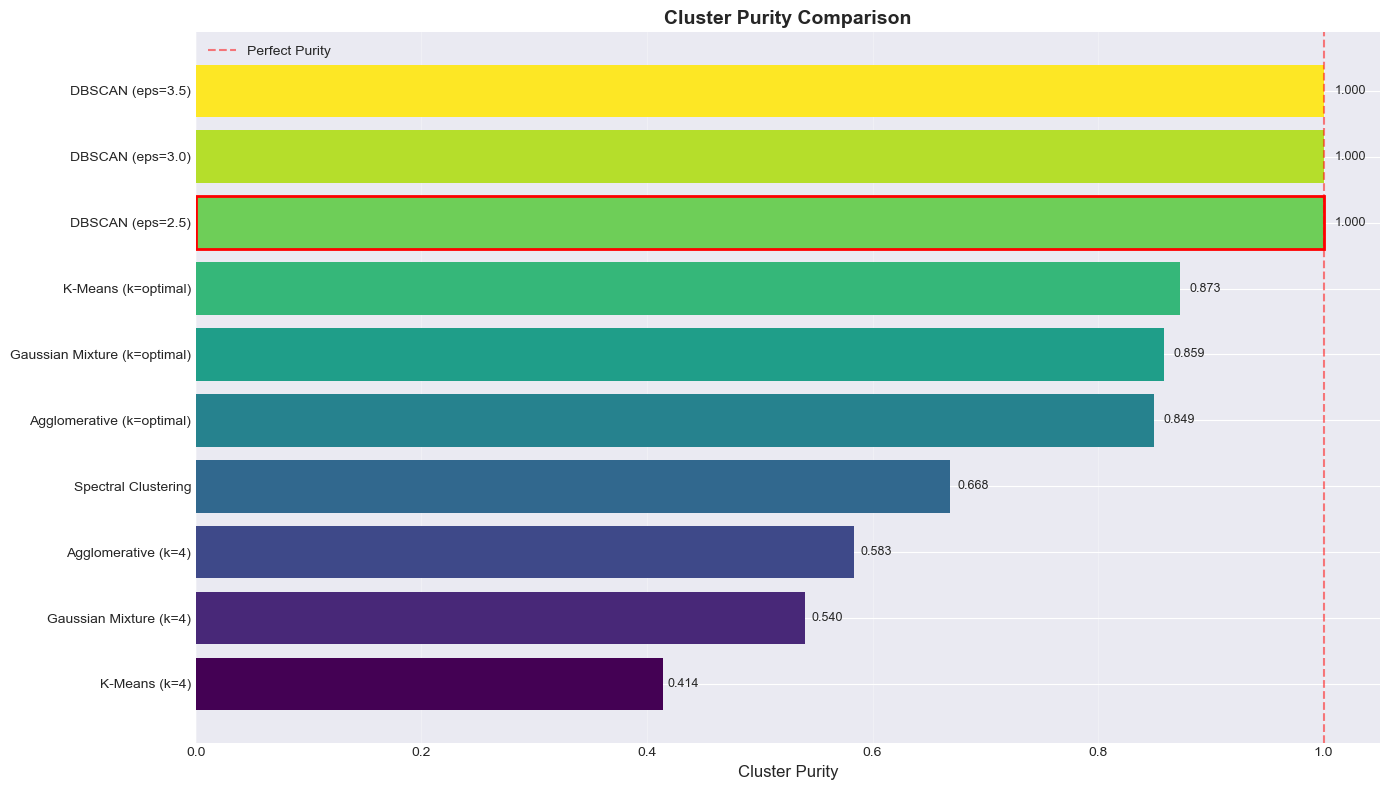

In [22]:
# Visualize cluster purity comparison
plt.figure(figsize=(14, 8))
algorithms = list(purity_results.keys())
purities = list(purity_results.values())

# Sort by purity for better visualization
sorted_idx = np.argsort(purities)
algorithms_sorted = [algorithms[i] for i in sorted_idx]
purities_sorted = [purities[i] for i in sorted_idx]

bars = plt.barh(algorithms_sorted, purities_sorted, 
                color=plt.cm.viridis(np.linspace(0, 1, len(algorithms))))
plt.xlabel('Cluster Purity', fontsize=12)
plt.title('Cluster Purity Comparison', fontweight='bold', fontsize=14)
plt.grid(True, alpha=0.3, axis='x')
plt.axvline(x=1.0, color='r', linestyle='--', alpha=0.5, label='Perfect Purity')

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width * 1.01, bar.get_y() + bar.get_height()/2,
             f'{width:.3f}', ha='left', va='center', fontsize=9)

# Highlight the best algorithm
best_idx = np.argmax(purities)
best_bar = bars[sorted_idx.tolist().index(best_idx)]
best_bar.set_edgecolor('red')
best_bar.set_linewidth(2)

plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('./Clustering/cluster_purity_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

<div style="
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 30px 40px ;
    background-color: #ffffff;
    border-radius: 12px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
    margin-bottom: 20px;
    color: #555;
    font-size: 20px;
">
🏆 Best Algorithm Analysis
</div>

In [23]:
# Analyze best clustering result
best_algorithm = max(purity_results, key=purity_results.get)
print(f"\nBest clustering algorithm: {best_algorithm}")
print(f"Purity: {purity_results[best_algorithm]:.3f}")
print(f"Clusters found: {results[best_algorithm]['n_clusters_found']}")

# Get labels from best algorithm
best_labels = cluster_labels[best_algorithm]

# Create cluster analysis DataFrame
cluster_analysis_df = pd.DataFrame({
    'true_language': true_labels,
    'cluster': best_labels
})

# Exclude noise if present
if -1 in best_labels:
    print(f"Noise points: {int(np.sum(best_labels == -1))}")
    cluster_analysis_df_clean = cluster_analysis_df[cluster_analysis_df['cluster'] != -1]
else:
    cluster_analysis_df_clean = cluster_analysis_df


# Create simplified confusion matrix (top clusters only)
confusion_matrix = pd.crosstab(
    cluster_analysis_df_clean['cluster'], 
    cluster_analysis_df_clean['true_language']
)

# If too many clusters, show only top ones
if confusion_matrix.shape[0] > 15:
    # Get cluster sizes
    cluster_sizes = confusion_matrix.sum(axis=1)
    top_clusters = cluster_sizes.nlargest(15).index
    confusion_matrix = confusion_matrix.loc[top_clusters]
    print(f"\nShowing top 15 clusters out of {len(cluster_sizes)}")

print("\nTop Clusters Language Distribution:")
print(confusion_matrix)




Best clustering algorithm: DBSCAN (eps=2.5)
Purity: 1.000
Clusters found: 17
Noise points: 2418

Showing top 15 clusters out of 17

Top Clusters Language Distribution:
true_language  German  Italian  Korean  Spanish
cluster                                        
9                   0        0      60        0
10                  0        0      60        0
5                   0        0      50        0
3                   0       38       0        0
11                  0        0      37        0
0                  32        0       0        0
13                  0        0       0       23
12                  0        0       0       21
14                  0        0       0       20
8                   0        0      13        0
4                   0       12       0        0
15                  0        0       0       12
6                   0        0      11        0
7                   0        0      11        0
1                  10        0       0        0


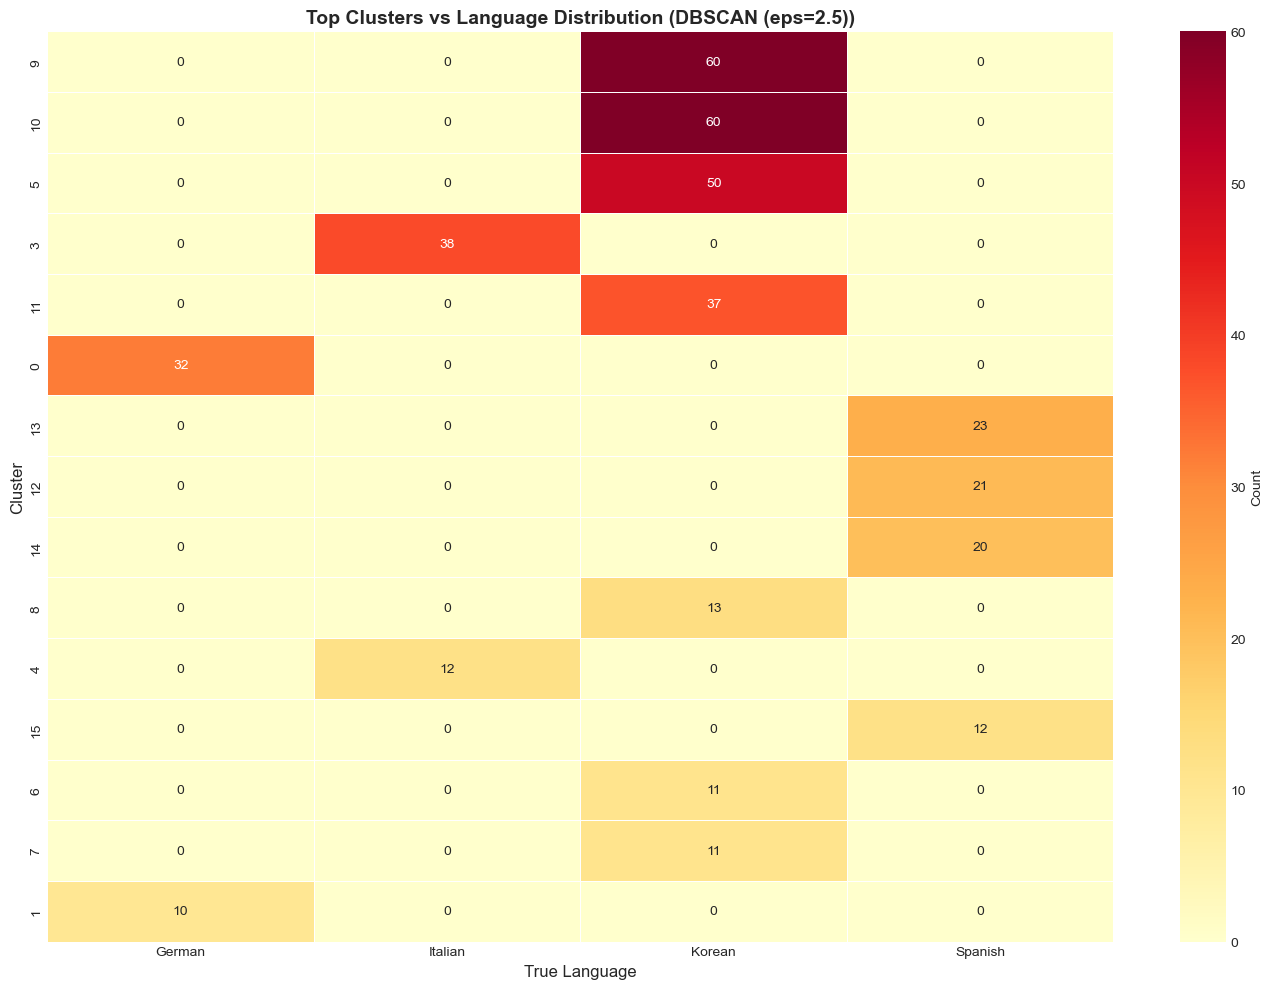

In [24]:
# Visualize cluster-language relationship
plt.figure(figsize=(14, 10))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='YlOrRd',
            cbar_kws={'label': 'Count'}, linewidths=0.5)
plt.title(f'Top Clusters vs Language Distribution ({best_algorithm})', 
          fontweight='bold', fontsize=14)
plt.xlabel('True Language', fontsize=12)
plt.ylabel('Cluster', fontsize=12)
plt.tight_layout()
plt.savefig('./Clustering/cluster_language_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [25]:
# Analyze cluster characteristics for best algorithm
print(f"\n{best_algorithm} - Cluster Characteristics:")
print("="*60)

# Get the report for best algorithm
best_report = reports[best_algorithm]

# Show top clusters
print(f"\nTop 10 Clusters (by size):")
print("-"*40)
print(f"{'Cluster':<10} {'Size':<8} {'Dominant Lang':<15} {'Purity':<8}")
print("-"*40)

for cluster_info in best_report['cluster_details'][:10]:
    print(f"{cluster_info['cluster_id']:<10} {cluster_info['size']:<8} "
          f"{cluster_info['dominant_language']:<15} {cluster_info['purity']:.3f}")

# Show noise if present
if best_report['noise_points'] > 0:
    print(f"\nNoise points: {best_report['noise_points']} "
          f"({best_report['noise_points']/len(best_labels)*100:.1f}% of data)")



DBSCAN (eps=2.5) - Cluster Characteristics:

Top 10 Clusters (by size):
----------------------------------------
Cluster    Size     Dominant Lang   Purity  
----------------------------------------
9          60       Korean          1.000
10         60       Korean          1.000
5          50       Korean          1.000
3          38       Italian         1.000
11         37       Korean          1.000
0          32       German          1.000
13         23       Spanish         1.000
12         21       Spanish         1.000
14         20       Spanish         1.000
8          13       Korean          1.000

Noise points: 2418 (84.9% of data)


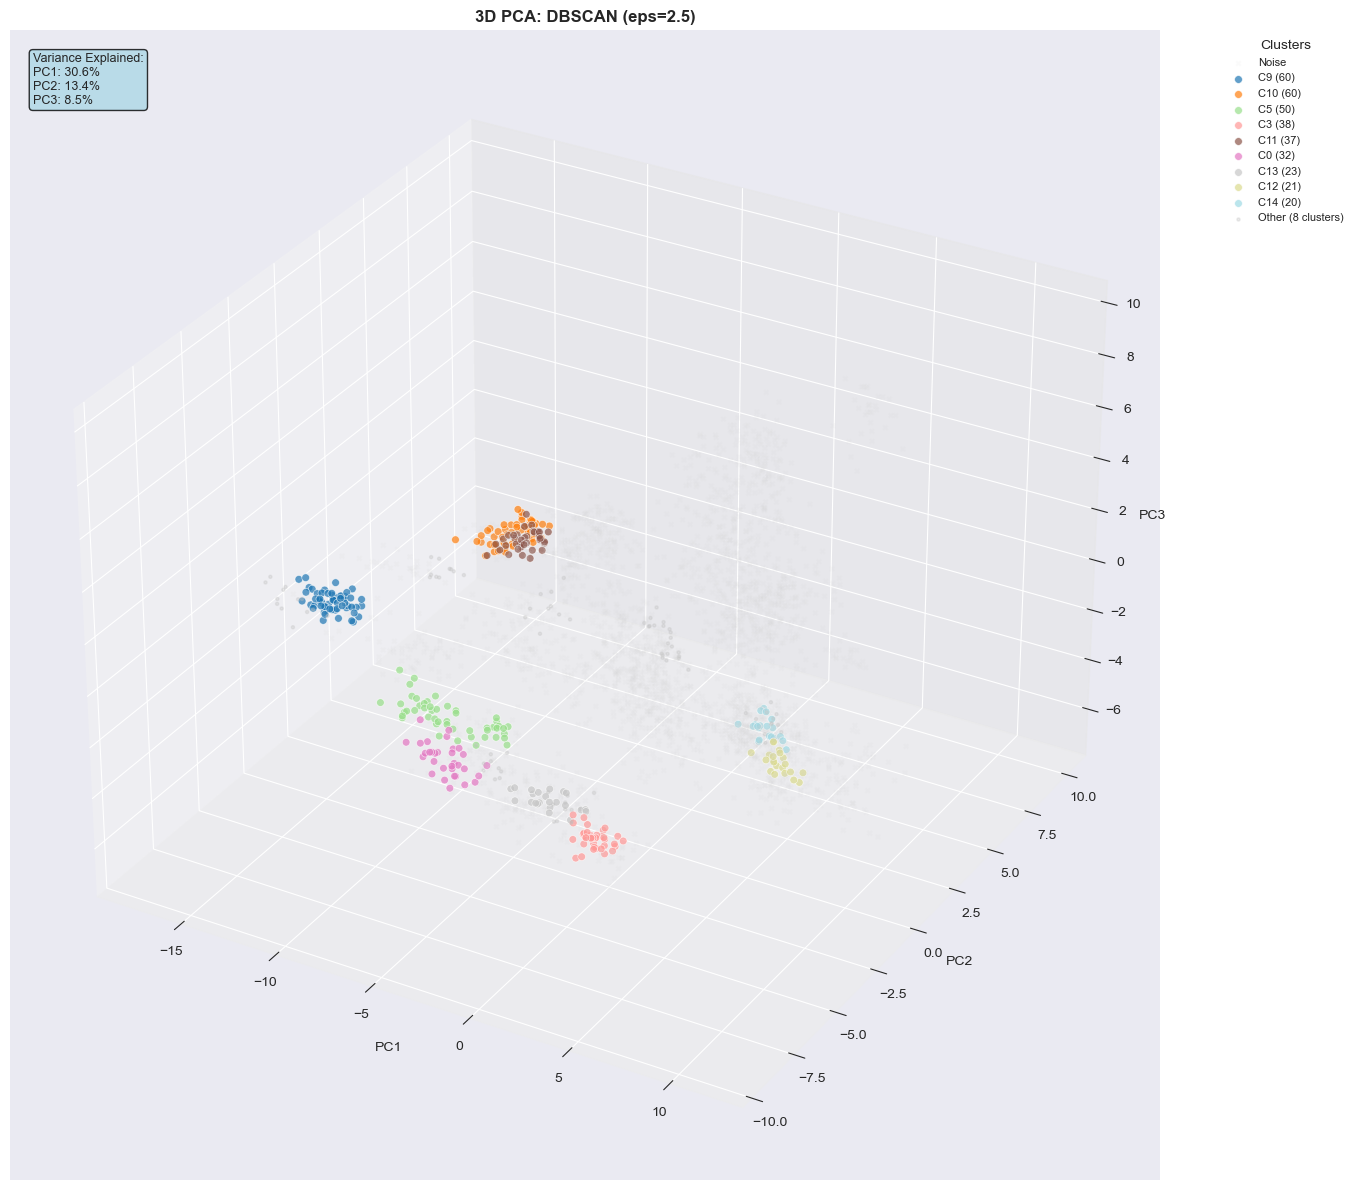

In [26]:
def visualize_3d_clusters_smart(X_3d, labels, title, max_clusters_to_show=12):
    fig = plt.figure(figsize=(16, 12))
    ax = fig.add_subplot(111, projection='3d')
    
    unique_labels = np.unique(labels)
    
    # Separate noise
    noise_mask = labels == -1
    if np.sum(noise_mask) > 0:
        ax.scatter(X_3d[noise_mask, 0], X_3d[noise_mask, 1], X_3d[noise_mask, 2],
                  c='lightgray', marker='x', s=10, alpha=0.1, label='Noise')
    
    # Get non-noise clusters
    non_noise_labels = [int(label) for label in unique_labels if label != -1]  # Convert to int
    
    if len(non_noise_labels) > max_clusters_to_show:
        # Group small clusters
        cluster_sizes = {}
        for label in non_noise_labels:
            cluster_sizes[label] = int(np.sum(labels == label))
        
        # Sort by size
        sorted_clusters = sorted(cluster_sizes.items(), key=lambda x: x[1], reverse=True)
        top_clusters = sorted_clusters[:max_clusters_to_show-1]
        other_clusters = sorted_clusters[max_clusters_to_show-1:]
        
        # Plot top clusters
        colors = plt.cm.tab20(np.linspace(0, 1, len(top_clusters)))
        for i, (label, size) in enumerate(top_clusters):
            mask = labels == label
            ax.scatter(X_3d[mask, 0], X_3d[mask, 1], X_3d[mask, 2],
                      c=[colors[i]], marker='o', s=30 + size/50,
                      alpha=0.7, label=f'C{label} ({size})',
                      edgecolors='w', linewidth=0.5)
        
        # Plot other clusters as one group
        if other_clusters:
            other_labels = [label for label, _ in other_clusters]
            other_mask = np.isin(labels, other_labels)
            if np.sum(other_mask) > 0:
                total_other = int(sum(size for _, size in other_clusters))
                ax.scatter(X_3d[other_mask, 0], X_3d[other_mask, 1], X_3d[other_mask, 2],
                          c='silver', marker='.', s=20,
                          alpha=0.3, label=f'Other ({len(other_clusters)} clusters)')
    else:
        # Plot all clusters
        colors = plt.cm.tab20(np.linspace(0, 1, len(non_noise_labels)))
        for i, label in enumerate(non_noise_labels):
            mask = labels == label
            size = int(np.sum(mask))
            ax.scatter(X_3d[mask, 0], X_3d[mask, 1], X_3d[mask, 2],
                      c=[colors[i]], marker='o', s=30 + size/50,
                      alpha=0.7, label=f'C{label} ({size})',
                      edgecolors='w', linewidth=0.5)
    
    ax.set_xlabel('PC1', fontsize=10)
    ax.set_ylabel('PC2', fontsize=10)
    ax.set_zlabel('PC3', fontsize=10)
    ax.set_title(title, fontweight='bold', fontsize=12)
    
    # Legend outside
    ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1), 
             fontsize=8, framealpha=0.9, title='Clusters')
    
    return fig, ax

# Create 3D PCA visualization
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

# Visualize best algorithm in 3D
fig, ax = visualize_3d_clusters_smart(X_pca_3d, best_labels, 
                                     f'3D PCA: {best_algorithm}', 
                                     max_clusters_to_show=10)

# Add variance information
variance_text = (f'Variance Explained:\n'
                f'PC1: {pca_3d.explained_variance_ratio_[0]*100:.1f}%\n'
                f'PC2: {pca_3d.explained_variance_ratio_[1]*100:.1f}%\n'
                f'PC3: {pca_3d.explained_variance_ratio_[2]*100:.1f}%')

ax.text2D(0.02, 0.98, variance_text, transform=ax.transAxes,
         fontsize=9, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.savefig('./Clustering/3d_pca_cluster_visualization.png', dpi=300, bbox_inches='tight')
plt.show()



DBSCAN Parameter Analysis:


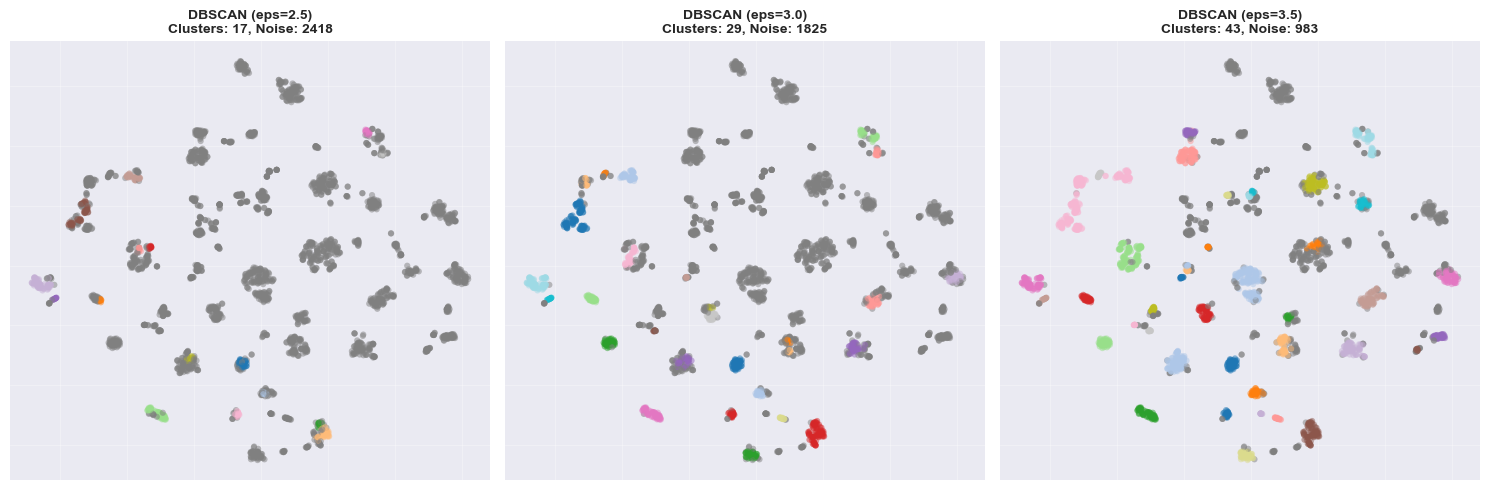

In [27]:
dbscan_algorithms = [name for name in clustering_algorithms.keys() if 'DBSCAN' in name]
if dbscan_algorithms:
    print("\nDBSCAN Parameter Analysis:")
    print("="*50)
    
    fig, axes = plt.subplots(1, len(dbscan_algorithms), figsize=(5*len(dbscan_algorithms), 5))
    if len(dbscan_algorithms) == 1:
        axes = [axes]
    
    for idx, name in enumerate(dbscan_algorithms):
        labels = cluster_labels[name]
        unique_labels = np.unique(labels)
        n_clusters = len(unique_labels) if -1 not in unique_labels else len(unique_labels) - 1
        noise_count = int(np.sum(labels == -1))
        
        # Simple visualization for DBSCAN
        colors = []
        for label in labels:
            if label == -1:
                colors.append('gray')
            else:
                colors.append(plt.cm.tab20(int(label) % 20))
        
        axes[idx].scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors, 
                         alpha=0.5, s=20, edgecolors='none')
        axes[idx].set_title(f'{name}\nClusters: {n_clusters}, Noise: {noise_count}', 
                           fontsize=10, fontweight='bold')
        axes[idx].set_xticklabels([])
        axes[idx].set_yticklabels([])
        axes[idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('./Clustering/dbscan_parameter_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()


<div style="
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 30px 40px ;
    background-color: #ffffff;
    border-radius: 12px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
    margin-bottom: 20px;
    color: #555;
    font-size: 20px;
">
💾 Save Models and Results
</div>

In [28]:
# Create timestamp for output files
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
output_dir = f'clustering_results_{timestamp}'
os.makedirs(output_dir, exist_ok=True)

# Helper function to convert numpy types to Python types
def convert_to_python_types(obj):
    """Convert numpy types to Python native types for JSON serialization"""
    if isinstance(obj, (np.integer, np.int32, np.int64)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float32, np.float64)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {key: convert_to_python_types(value) for key, value in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_python_types(item) for item in obj]
    elif isinstance(obj, (str, int, float, bool, type(None))):
        return obj
    else:
        return str(obj)  # Convert other types to string as fallback

# Prepare results for JSON serialization
clustering_results = {
    'metadata': {
        'timestamp': timestamp,
        'dataset_shape': list(features_df.shape),  # Convert tuple to list
        'n_languages': int(len(true_labels.unique())),
        'languages': convert_to_python_types(list(true_labels.unique())),
        'optimal_k_silhouette': int(optimal_k_silhouette),
        'optimal_k_calinski': int(optimal_k_calinski),
        'optimal_k_davies': int(optimal_k_davies)
    },
    'algorithms': list(cluster_labels.keys()),
    'labels': {name: convert_to_python_types(labels.tolist()) for name, labels in cluster_labels.items()},
    'metrics': convert_to_python_types(results_df.to_dict('index')),
    'purity_scores': convert_to_python_types(purity_results),
    'best_algorithm': best_algorithm,
    'best_labels': convert_to_python_types(best_labels.tolist()),
    'true_labels': convert_to_python_types(true_labels.tolist()),
    'language_map': convert_to_python_types(language_map),
    'cluster_reports': convert_to_python_types(reports)
}

# Save clustering results
with open(f'{output_dir}/clustering_results.json', 'w') as f:
    json.dump(clustering_results, f, indent=2)

# Save best clustering model
best_model = clustering_algorithms[best_algorithm]
if hasattr(best_model, 'fit'):
    model_filename = f'{output_dir}/best_clustering_model.pkl'
    joblib.dump(best_model, model_filename)

# Save results DataFrame
results_df.to_csv(f'{output_dir}/clustering_metrics.csv')

# Save detailed cluster reports as CSV
for name, report in reports.items():
    # Convert cluster details to DataFrame
    details_df = pd.DataFrame(report['cluster_details'])
    if not details_df.empty:
        safe_name = name.replace(" ", "_").replace("(", "").replace(")", "").replace("=", "")
        details_df.to_csv(f'{output_dir}/cluster_details_{safe_name}.csv', index=False)
